<a href="https://colab.research.google.com/github/itsSolG/sales-analysis-and-forecasting/blob/main/notebooks/02_sales_forecasting.ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sales Forecasting using Machine Learning**

## Objective

The goal of this notebook is to build a simple machine learning model to predict future sales based on historical data.

##Import Libraries

In this section, we import the necessary libraries for data manipulation and machine learning.

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt


##Data Loading

The dataset is loaded and the date column is converted into datetime format for time-based analysis.

In [15]:
df = pd.read_csv("data/superstore.csv")
df["Order Date"] = pd.to_datetime(df["Order.Date"])

##Feature Engineering
We extract the year and month from the order date to use them as numerical features for the model.

In [20]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

## Data Aggregation

Sales data is aggregated at a monthly level to simplify the time series and reduce noise.

In [27]:
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()
monthly_sales.head()

,Year,Month,Sales
0,2011,1,98902
1,2011,2,91152
2,2011,3,145726
3,2011,4,116927
4,2011,5,146762


## Define Variables

We define the input variables (features) and the target variable for the model.

In [24]:
X = monthly_sales[["Year", "Month"]]
y = monthly_sales["Sales"]

## Train-Test Split

The dataset is divided into training and testing sets to evaluate the model's performance.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

##Model Training
A linear regression model is trained to learn the relationship between time and sales.

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

##Predictions

In [29]:
predictions = model.predict(X_test)

### Insight

A simple linear regression model was used to predict sales based on time (year and month). This provides a basic approach to understanding future sales trends.

##Model Evaluation

In [30]:
from sklearn.metrics import mean_absolute_error

In [32]:
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 36793.82581278682


### Model Insight

The model achieves a mean absolute error of approximately 36,793, indicating that predictions deviate from actual sales by this amount on average.

Considering the scale of monthly sales, this level of error suggests that the model captures general trends but lacks precision for accurate forecasting. This is expected given the simplicity of the linear regression model and the limited number of features used.

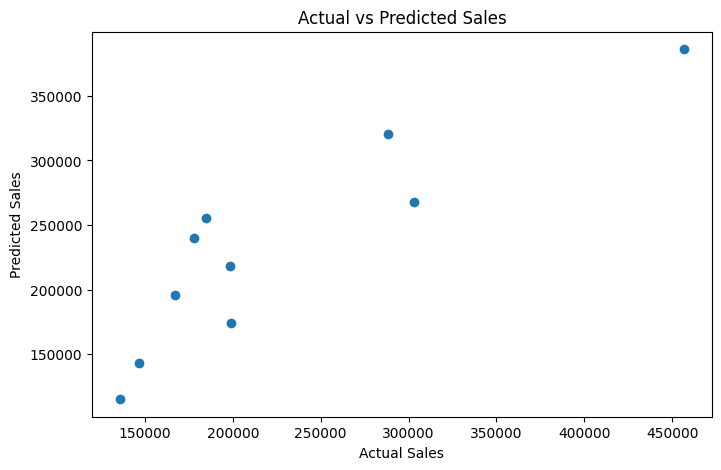

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

### Model Insight

The scatter plot shows a high level of dispersion between actual and predicted values, indicating that the model struggles to accurately capture sales behavior.

While the model is able to reflect general trends, it lacks the complexity needed to account for variability in the data. This suggests that additional features and more advanced models would be required to improve prediction accuracy.

## Conclusion

A simple linear regression model was implemented to predict sales based on time variables.

Although the model captures general trends, its performance is limited due to the simplicity of the features used. The relatively high error and dispersed predictions indicate that additional variables and more advanced modeling techniques are needed to improve accuracy.

This model serves as a baseline for future improvements in sales forecasting.